In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)
for sub_folder in os.listdir("Assets"):
    sub_folder_files = os.listdir(os.path.join("Assets", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("Assets", sub_folder, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 450
Kelas: ['Cassava___bacterial_blight', 'Cassava___brown_streak_disease', 'Cassava___green_mottle', 'Cassava___healthy', 'Cassava___mosaic_disease']


In [3]:
def dilasi(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='constant', constant_values=0)

    hasil = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            hasil[i, j] = np.max(window)

    return hasil

def erosi(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='constant', constant_values=255)

    hasil = np.zeros_like(image)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            hasil[i, j] = np.min(window)

    return hasil

def closing(image, kernel_size=3):
    dilated = dilasi(image, kernel_size)
    closed = erosi(dilated, kernel_size)

    return closed

In [4]:
def manual_clahe(img, clip_limit=2.0, tile_size=8):
    """
    CLAHE (Contrast Limited Adaptive Histogram Equalization) manual.
    Tidak menggunakan cv2.createCLAHE().
    """
    h, w = img.shape
    pad_h = (tile_size - h % tile_size) % tile_size
    pad_w = (tile_size - w % tile_size) % tile_size
    padded = np.pad(img, ((0, pad_h), (0, pad_w)), mode='reflect')
    ph, pw = padded.shape
    tiles_y, tiles_x = ph // tile_size, pw // tile_size
    luts = np.zeros((tiles_y, tiles_x, 256), dtype=np.uint8)

    for ty in range(tiles_y):
        for tx in range(tiles_x):
            tile = padded[ty*tile_size:(ty+1)*tile_size, tx*tile_size:(tx+1)*tile_size]
            hist = np.bincount(tile.flatten(), minlength=256).astype(np.float32)
            clip_val = clip_limit * tile.size / 256
            excess = np.sum(np.maximum(hist - clip_val, 0))
            hist = np.minimum(hist, clip_val) + excess / 256
            cdf = np.cumsum(hist)
            cdf_min = cdf[cdf > 0].min()
            lut = np.round((cdf - cdf_min) / (tile.size - cdf_min) * 255)
            luts[ty, tx] = np.clip(lut, 0, 255).astype(np.uint8)

    output = np.zeros_like(padded, dtype=np.float32)
    for y in range(ph):
        for x in range(pw):
            ty = min(y // tile_size, tiles_y - 1)
            tx = min(x // tile_size, tiles_x - 1)
            output[y, x] = luts[ty, tx, padded[y, x]]
    return output[:h, :w].astype(np.uint8)

In [5]:
IMG_SIZE = (128, 128)

def pre_proses_P3(image, target_size=IMG_SIZE):

    # Resize
    resized = cv.resize(image, target_size)

    # Grayscale
    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    # CLAHE manual
    img = manual_clahe(gray, tile_size=32, clip_limit=5)

    # Morfologi Closing manual
    img = closing(img, kernel_size=3)

    return img


def percobaan3(img):
    return pre_proses_P3(img)

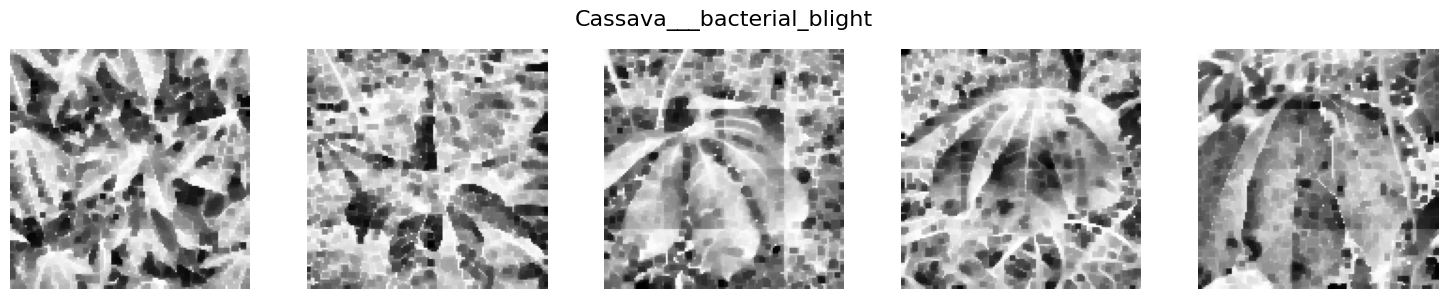

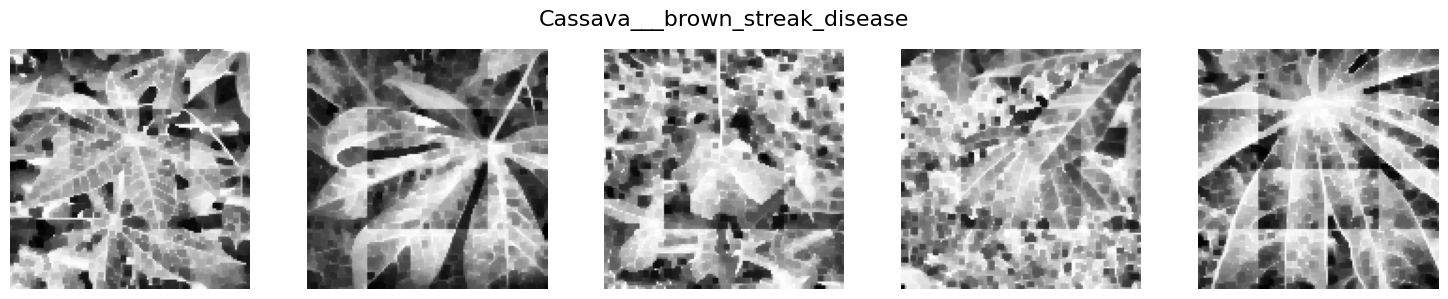

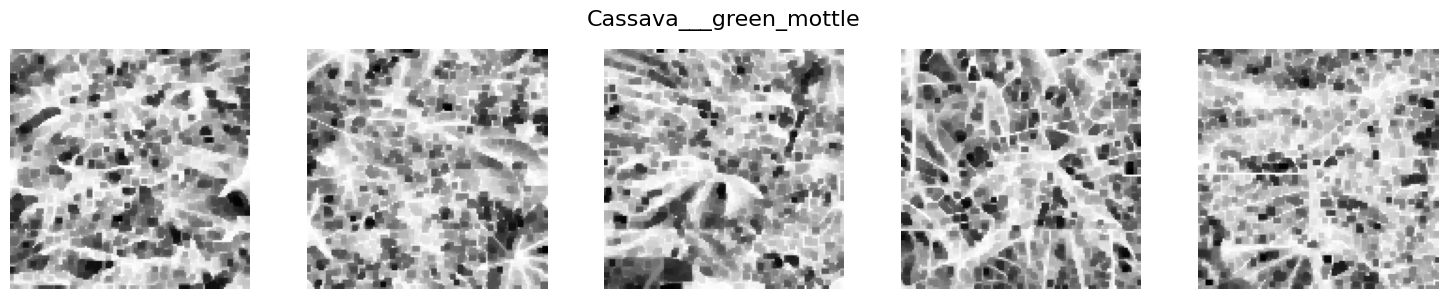

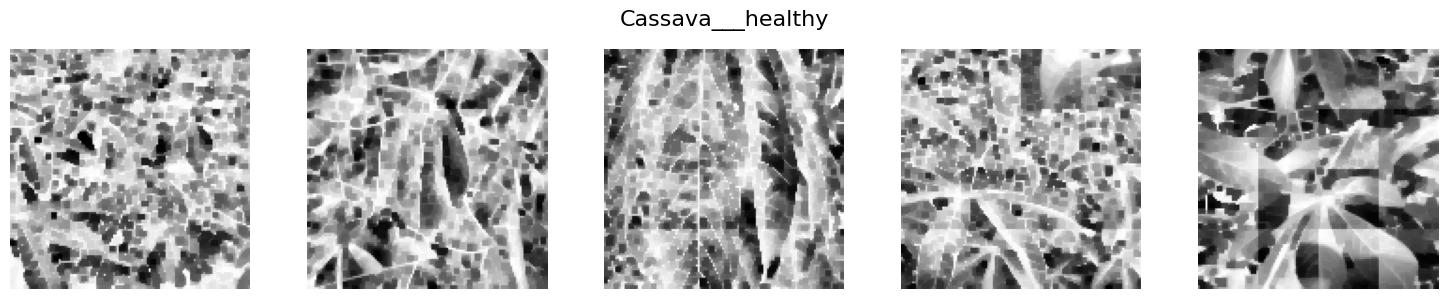

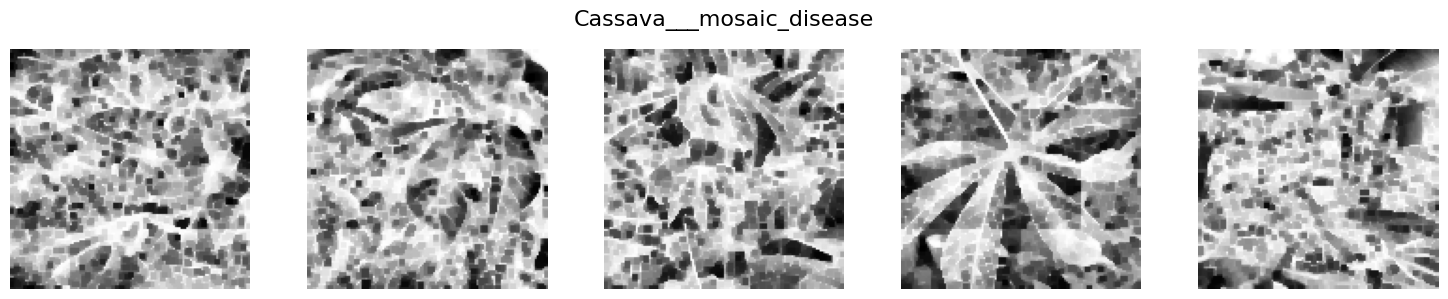

In [6]:
def percobaan3(img):
    hasil = pre_proses_P3(img)
    return hasil

dataPreprocessed = [percobaan3(img) for img in data]
unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]
    fig, axs = plt.subplots(1, 5, figsize=(15, 3)) 
    fig.suptitle(label, fontsize=16)

    for k in range(5):
        ax = axs[k]
        
        if k < len(idxs):
            ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')

        ax.axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.85)
    plt.show()

In [7]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image.astype(np.uint8), [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [8]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [9]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 450 citra.


In [10]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('./Hasil_ekstraksi/hasil_ekstraksi_Percobaan3.csv', index=False)

hasilEkstrak = pd.read_csv('./Hasil_ekstraksi/hasil_ekstraksi_Percobaan3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,Cassava___bacterial_blight_1.jpg,Cassava___bacterial_blight,1167.728469,1753.940914,1089.070866,1782.237026,0.438097,0.237997,0.445649,0.234302,...,0.000993,0.000338,0.030868,0.018555,0.031515,0.018396,0.873551,0.810596,0.882300,0.807550
1,Cassava___bacterial_blight_2.jpg,Cassava___bacterial_blight,1017.131951,1671.167958,1207.655327,1865.286565,0.474448,0.263343,0.471497,0.264569,...,0.001278,0.000469,0.036192,0.021618,0.035742,0.021649,0.864348,0.777591,0.839932,0.751752
2,Cassava___bacterial_blight_3.jpg,Cassava___bacterial_blight,825.633858,1465.137950,914.093996,1355.165044,0.448313,0.249179,0.460465,0.246932,...,0.001237,0.000438,0.034334,0.021186,0.035173,0.020937,0.875432,0.778192,0.861958,0.794840
3,Cassava___bacterial_blight_4.jpg,Cassava___bacterial_blight,922.990281,1599.762106,1002.103900,1460.334925,0.439858,0.230076,0.440734,0.238427,...,0.001101,0.000385,0.032832,0.019240,0.033178,0.019621,0.876401,0.785840,0.866251,0.804464
4,Cassava___bacterial_blight_5.jpg,Cassava___bacterial_blight,874.714136,1393.797880,804.911233,1299.379255,0.461315,0.269462,0.486193,0.276378,...,0.001658,0.000661,0.038859,0.025134,0.040715,0.025718,0.859177,0.774767,0.870704,0.790036
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,Cassava___mosaic_disease_86.jpg,Cassava___mosaic_disease,816.090920,1705.993986,1174.468996,1507.962490,0.477864,0.259374,0.469688,0.260123,...,0.001273,0.000482,0.036757,0.021701,0.035672,0.021953,0.883674,0.755731,0.832186,0.784062
446,Cassava___mosaic_disease_87.jpg,Cassava___mosaic_disease,864.857960,1722.655465,1202.113374,1648.835266,0.443425,0.237643,0.439325,0.236151,...,0.001062,0.000375,0.032619,0.019464,0.032590,0.019367,0.888658,0.777778,0.845086,0.787309
447,Cassava___mosaic_disease_88.jpg,Cassava___mosaic_disease,1064.797429,1842.574369,1220.568036,1775.812016,0.458299,0.249586,0.466435,0.249923,...,0.001193,0.000397,0.033759,0.019881,0.034534,0.019931,0.853466,0.745207,0.831903,0.754434
448,Cassava___mosaic_disease_89.jpg,Cassava___mosaic_disease,974.972010,1787.274661,1219.527744,1702.750202,0.464239,0.251581,0.463527,0.248256,...,0.001266,0.000436,0.035756,0.020928,0.035584,0.020877,0.851273,0.726262,0.813652,0.739150


Fitur sebelum seleksi: 28
Fitur setelah seleksi: 17
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity45', 'Homogeneity90', 'Dissimilarity45', 'Dissimilarity135', 'Entropy0', 'Entropy45', 'Entropy90', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


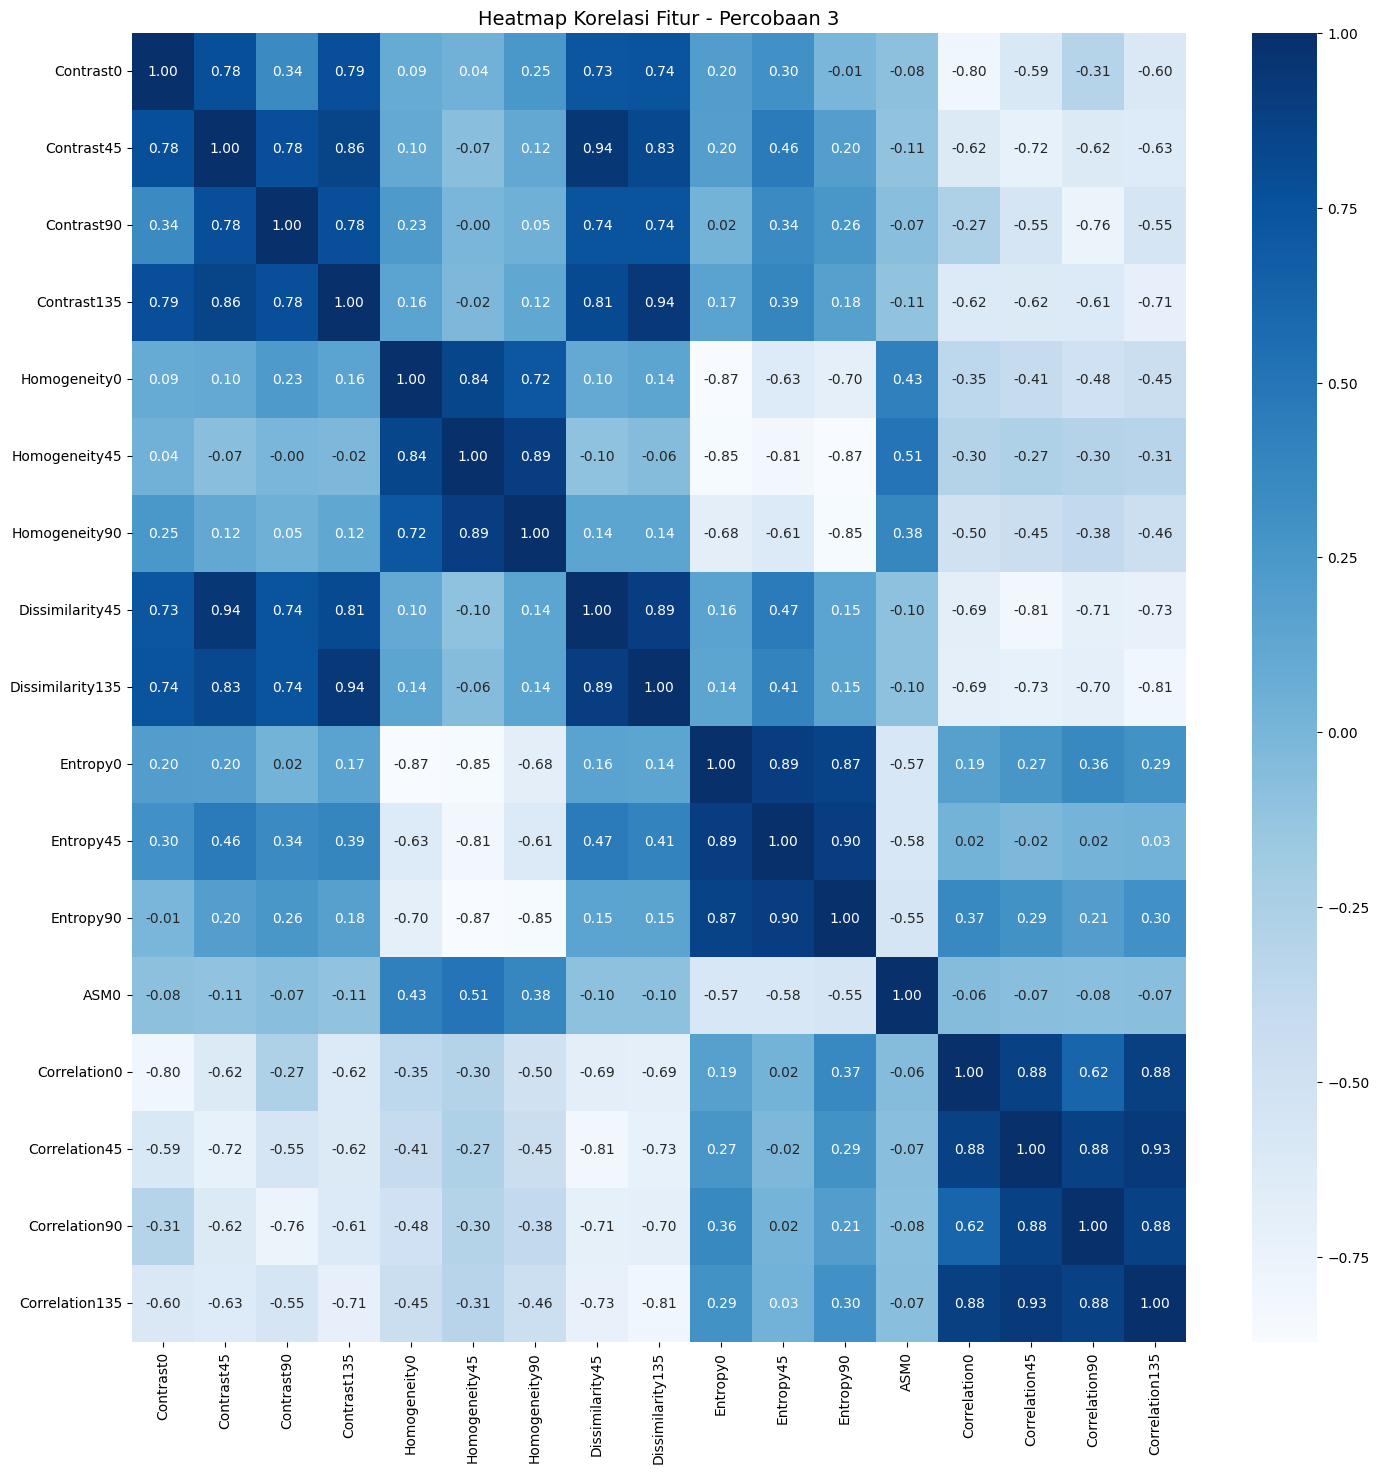

In [11]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}")
print(f"Fitur setelah seleksi: {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (360, 17)
X_test shape:  (90, 17)


In [13]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

In [14]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))
    
rf  = RandomForestClassifier(n_estimators=5, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

In [15]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.92      0.91      0.92        66
Cassava___brown_streak_disease       0.85      0.92      0.88        75
        Cassava___green_mottle       0.91      0.96      0.94        78
             Cassava___healthy       0.94      0.84      0.88        73
      Cassava___mosaic_disease       0.90      0.88      0.89        68

                      accuracy                           0.90       360
                     macro avg       0.90      0.90      0.90       360
                  weighted avg       0.90      0.90      0.90       360

[[60  4  0  1  1]
 [ 3 69  0  0  3]
 [ 0  1 75  0  2]
 [ 1  5  5 61  1]
 [ 1  2  2  3 60]]
Accuracy: 0.9027777777777778

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.48      0.42      0.44        24
Cassava___brown_streak_disease    

In [16]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.46      0.39      0.43        66
Cassava___brown_streak_disease       0.39      0.51      0.44        75
        Cassava___green_mottle       0.38      0.63      0.47        78
             Cassava___healthy       0.50      0.34      0.41        73
      Cassava___mosaic_disease       0.54      0.22      0.31        68

                      accuracy                           0.42       360
                     macro avg       0.45      0.42      0.41       360
                  weighted avg       0.45      0.42      0.41       360

[[26 20  8  8  4]
 [11 38 17  6  3]
 [ 5 13 49  5  6]
 [ 9 18 21 25  0]
 [ 5  8 34  6 15]]
Accuracy: 0.425

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.33      0.21      0.26        24
Cassava___brown_streak_disease       0.19     

In [17]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport( y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport( y_test, y_pred)


------Training Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.47      0.64      0.54        66
Cassava___brown_streak_disease       0.49      0.53      0.51        75
        Cassava___green_mottle       0.60      0.63      0.61        78
             Cassava___healthy       0.59      0.32      0.41        73
      Cassava___mosaic_disease       0.56      0.56      0.56        68

                      accuracy                           0.53       360
                     macro avg       0.54      0.53      0.53       360
                  weighted avg       0.54      0.53      0.53       360

[[42 12  1  6  5]
 [20 40  3  5  7]
 [ 7  9 49  1 12]
 [15 16 13 23  6]
 [ 6  4 16  4 38]]
Accuracy: 0.5333333333333333

------Testing Set------
                                precision    recall  f1-score   support

    Cassava___bacterial_blight       0.48      0.46      0.47        24
Cassava___brown_streak_disease   

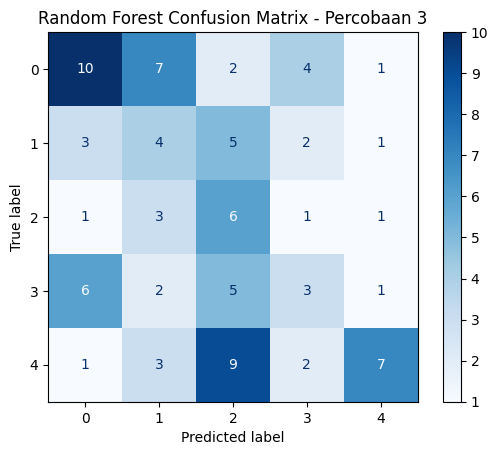

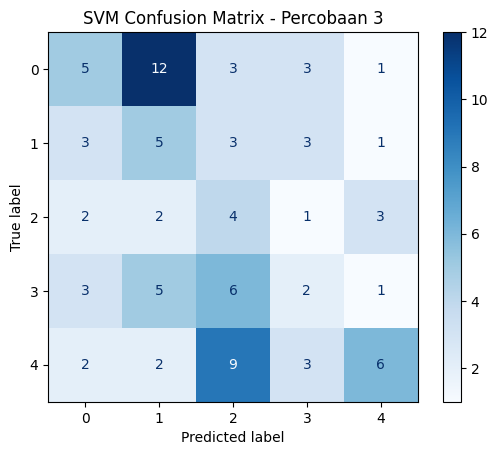

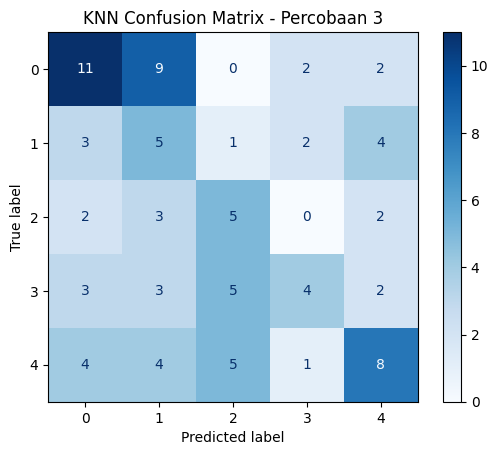

In [18]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 3")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 3")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 3")

In [19]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('./Hasil_klasifikasi/hasil_klasifikasi_Percobaan3.csv', index=False)
df_hasil

,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.902778,0.333333,0.394479,0.333333,0.341544
1,SVM,0.425000,0.244444,0.295977,0.244444,0.250183
2,KNN,0.533333,0.366667,0.396518,0.366667,0.371074
